<center>

![](recursos/img/logoitqv1.jpg)

</center>

## PAO26-26-Python 1, Transformaciones

<center>

![](recursos/img/python_logo.png)

</center>

*Cynthia Cuñez*

 Repositorio: <a href="https://github.com/cynthia0206/machine12926nocturno/blob/main/PAO26-07-12-TRANSFORMACIONES.ipynb">Link del repositorio de Github</a>

 *https://github.com/cynthia0206/machine12926nocturno/blob/main/PAO26-07-12-TRANSFORMACIONES.ipynb

Image dimensions:  (256, 256, 3)


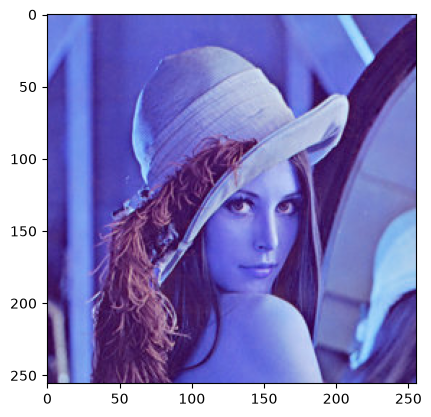

In [3]:
# READ AN IMAGE
# pip install opencv-python o conda install opencv-python
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = cv2.imread('images/Lena_RGB.png')
print('Image dimensions: ', np.shape(img))
plt.imshow(img, cmap='gray')
plt.show()

In [4]:
# Extraer por separado la imagen de grises de cada canal
R = img[:,:,2]
G = img[:,:,1]
B = img[:,:,0]

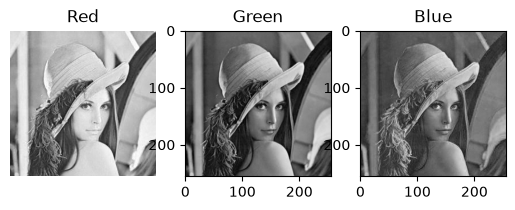

In [5]:
# Visualizar los canales en un subplot
fig, ax = plt.subplots(1,3)
ax[0].imshow(R, cmap='gray'), ax[0].set_title('Red'), ax[0].axis('off')
ax[1].imshow(G, cmap='gray'), ax[1].set_title('Green')
ax[2].imshow(B, cmap='gray'), ax[2].set_title('Blue')
plt.show()

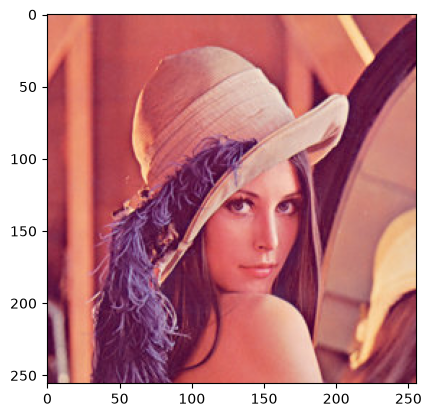

In [6]:
# Convertir BGR en RGB
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_img, cmap='gray')
plt.show()

### TRANSFORMACIONES DE INTENSIDAD

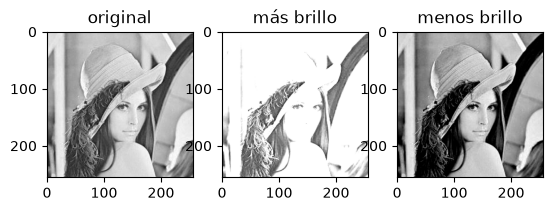

In [8]:
# CAMBIO DE BRILLO
img = cv2.imread('images/Lena_RGB.png')
img = img[:,:,2] # red color
mas_brillo = 100
menos_brillo = -100

mas_brillo_img = cv2.add(img, mas_brillo) # Importante el "cv2.add" en vez de "+"
menos_brillo_img = cv2.add(img, menos_brillo)

fig, ax = plt.subplots(1,3)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mas_brillo_img, cmap='gray'), ax[1].set_title('más brillo')
ax[2].imshow(menos_brillo_img, cmap='gray'), ax[2].set_title('menos brillo')
plt.show()

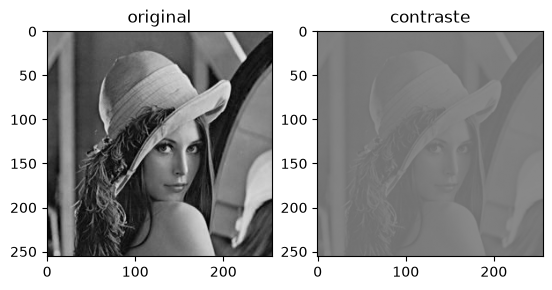

In [9]:
# CAMBIO DE CONTRASTE de acuerdo con el programa GIMP
img = cv2.imread('images/Lena_RGB.png')
img = img[:,:,1] # canal verde
contraste = -100
f = 131*(contraste + 127)/(127*(131-contraste))
alpha_c = f
gamma_c = 127*(1-f)
contrast_img = cv2.addWeighted(img, alpha_c, img, 0, gamma_c)

fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255), ax[0].set_title('original')
ax[1].imshow(contrast_img, cmap='gray', vmin=0, vmax=255), ax[1].set_title('contraste')
plt.show()

### CONVERSIONES DEL ESPACIO DE COLOR

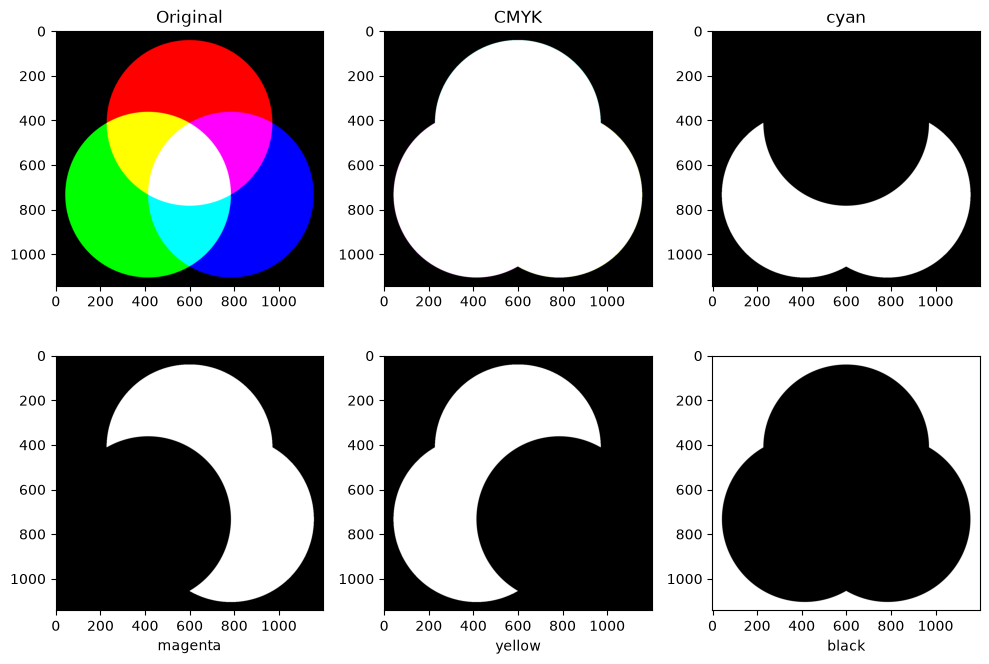

In [18]:
# RGB to CMYK
import numpy as np
from skimage import io
import matplotlib.pyplot as plt
import cv2

# Cargar la imagen
img = io.imread('images/colores.png')
rgb = img.copy()

# Normalizar los valores de 0-255 a 0-1
rgb_p = rgb.astype('float32') / 255.0

# Extraer los canales individuales R, G, B
R = rgb_p[:, :, 0]
G = rgb_p[:, :, 1]
B = rgb_p[:, :, 2]

# Calcular el canal K (Negro) e ignorar advertencias de división por cero
with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)
    
    # Extrae los canales de acuerdo con la ecuación
    C = (1 - R - K) / (1 - K)
    M = (1 - G - K) / (1 - K)
    Y = (1 - B - K) / (1 - K)
    
    # Si K es 1 (negro absoluto), C, M y Y deben ser 0.
    # Reemplazamos los valores NaN resultantes de la división por 0.
    C = np.nan_to_num(C)
    M = np.nan_to_num(M)
    Y = np.nan_to_num(Y)

# Apilar los canales de vuelta y multiplicar por 255 para recuperar el rango 0-255
CMYK = (np.dstack((C, M, Y, K)) * 255).astype('uint8')
C, M, Y, K = cv2.split(CMYK)

# Graficar
fig, ax = plt.subplots(2, 3, figsize=(10, 7))
ax[0,0].imshow(img) # Nota: Se quita cmap='gray' para ver la original a color
ax[0,0].set_title('Original')
ax[0,1].imshow(CMYK) # Nota: Quitamos cmap='gray' para ver el CMYK combinado
ax[0,1].set_title('CMYK')

# Mostrar cada componente en escala de grises
ax[0,2].imshow(C, cmap='gray')
ax[0,2].set_title('cyan')
ax[1,0].imshow(M, cmap='gray')
ax[1,0].set_xlabel('magenta')
ax[1,1].imshow(Y, cmap='gray')
ax[1,1].set_xlabel('yellow')
ax[1,2].imshow(K, cmap='gray')
ax[1,2].set_xlabel('black')

plt.tight_layout()
plt.show()

In [19]:
# Otras conversiones
from skimage import io
img = cv2.imread('images/Lena_RGB.png')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # gray-scale
HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) # (H)ue, (S)aturation and (V)alue
Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab) # (L)uminosidad, a-b colores complementarios
YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb) # Y-Luma, Cr-Cb crominancia rojo y azul

### TRANSFORMACIONES GEOMÉTRICAS

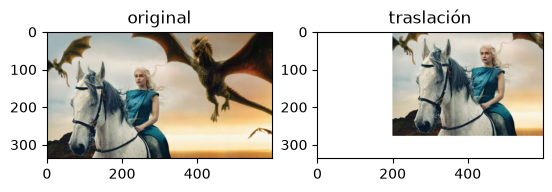

In [20]:
# TRASLACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape
M = np.float32([[1,0,200],[0,1,-60]]) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('traslación')
plt.show()

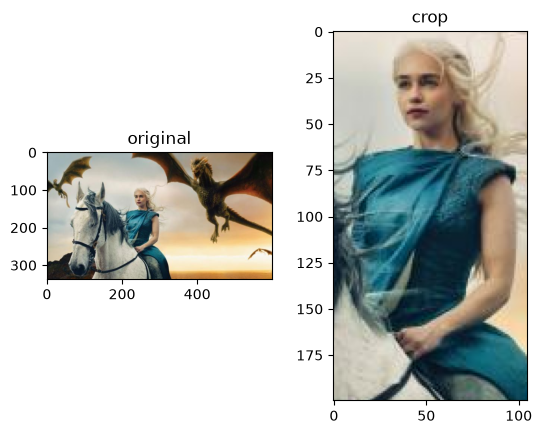

In [21]:
# CROPPING
img = io.imread('images/GOT.png')
new_img = img[90:290, 200:305]

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('crop')
plt.show()

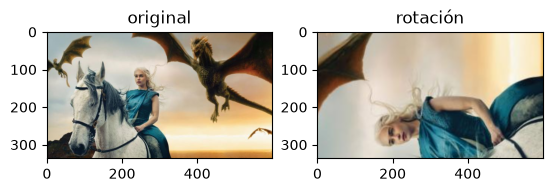

In [22]:
# ROTACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape
M = cv2.getRotationMatrix2D((cols/2,rows/2),angle=90,scale=2) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('rotación')
plt.show()

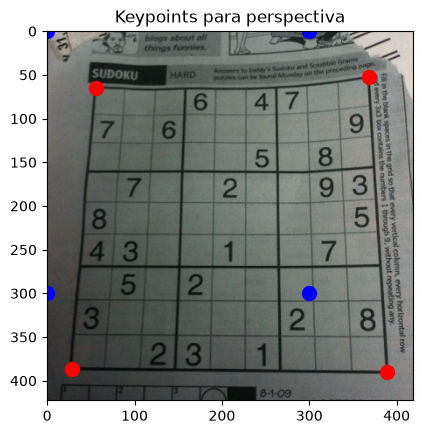

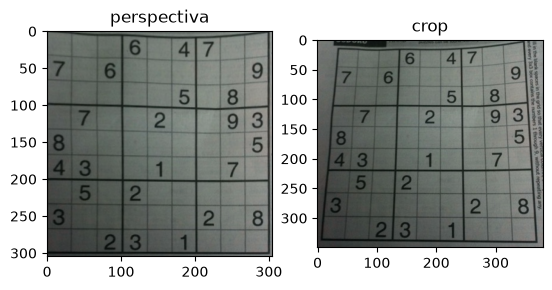

In [23]:
# PERSPECTIVA
img = cv2.imread('images/sudoku.png')
rows, cols, ch = img.shape
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

plt.imshow(img, cmap='gray')
for i in range(0,4):
    plt.plot(pts1[i,0], pts1[i,1], 'or', markersize=10)
    plt.plot(pts2[i,0], pts2[i,1], 'ob', markersize=10)
plt.title('Keypoints para perspectiva')
plt.show()

M = cv2.getPerspectiveTransform(pts1,pts2) # Defino la matriz de transformación
pers = cv2.warpPerspective(img,M,(305,305)) # Aplico la transformación
crop = img[50:400,20:400]

figs, ax = plt.subplots(1,2)
ax[0].imshow(pers, cmap='gray'), ax[0].set_title('perspectiva')
ax[1].imshow(crop, cmap='gray'), ax[1].set_title('crop')
plt.show()

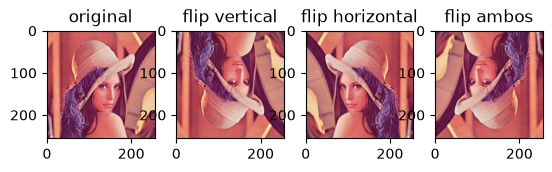

In [24]:
# FLIPPING
# Leer la imagen "Lena_RGB.png" en formato RGB
img = io.imread('images/Lena_RGB.png')
# Voltear la imagen para conseguir las siguientes transformaciones. Utiliza el método "cv2.flip()"
flipVertical = cv2.flip(img,0)
flipHorizontal = cv2.flip(img,1)
flipBoth = cv2.flip(img,-1)

figs, ax = plt.subplots(1,4)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(flipVertical, cmap='gray'), ax[1].set_title('flip vertical')
ax[2].imshow(flipHorizontal, cmap='gray'), ax[2].set_title('flip horizontal')
ax[3].imshow(flipBoth, cmap='gray'), ax[3].set_title('flip ambos')
plt.show()